In [3]:
import numpy as np 
import polars as pl
df = pl.DataFrame(
    {
        "a": [1, 2, 3, 4, 5],
        "b": [6, 7, 8, 9, 10],
    }
)
ser1 = series = pl.Series("a", [1, 2, 3, 4, 5])
ser2 = series = pl.Series("b", [6, 7, 8, 9, 10])
print(ser1 + ser2)


shape: (5,)
Series: 'a' [i64]
[
	7
	9
	11
	13
	15
]


In [4]:
import numpy as np
import polars as pl

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

np.random.seed(42)

num_samples = 200

study_hours = np.random.randint(1, 12, num_samples)
sleep_hours = np.random.randint(4, 9, num_samples)
attendance = np.random.randint(50, 100, num_samples)
assignments = np.random.randint(1, 10, num_samples)

marks = (
    study_hours * 5 +
    sleep_hours * 2 +
    attendance * 0.5 +
    assignments * 3 +
    np.random.normal(0, 5, num_samples)
)

data = {
    "Study_Hours": study_hours,
    "Sleep_Hours": sleep_hours,
    "Attendance": attendance,
    "Assignments_Completed": assignments,
    "Marks": marks
}

df = pl.DataFrame(data)

df = df.with_columns([
    (
        pl.col("Study_Hours") *
        pl.col("Assignments_Completed")
    ).alias("Study_Assignment_Score"),

    (
        pl.col("Attendance") /
        100
    ).alias("Attendance_Ratio")
])

high_performers = df.filter(
    pl.col("Marks") > 75
)

average_marks = df.select(
    pl.col("Marks").mean()
)

top_students = df.sort(
    "Marks",
    descending=True
).head(10)

X = np.array(
    df.select([
        "Study_Hours",
        "Sleep_Hours",
        "Attendance",
        "Assignments_Completed",
        "Study_Assignment_Score",
        "Attendance_Ratio"
    ])
)

y = np.array(df["Marks"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),

    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=42
        )
    )
])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

mse = mean_squared_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

new_student = np.array([
    [8, 6, 90, 7, 56, 0.90]
])

predicted_marks = pipeline.predict(
    new_student
)

comparison = pl.DataFrame({
    "Actual_Marks": y_test,
    "Predicted_Marks": predictions
})

comparison = comparison.with_columns(
    (
        pl.col("Actual_Marks") -
        pl.col("Predicted_Marks")
    ).abs().alias("Error")
)

feature_importance = pl.DataFrame({
    "Feature": [
        "Study_Hours",
        "Sleep_Hours",
        "Attendance",
        "Assignments_Completed",
        "Study_Assignment_Score",
        "Attendance_Ratio"
    ],

    "Importance": pipeline.named_steps[
        "model"
    ].feature_importances_
})

feature_importance = feature_importance.sort(
    "Importance",
    descending=True
)

print("\nDataset:")
print(df)

print("\nHigh Performers:")
print(high_performers)

print("\nAverage Marks:")
print(average_marks)

print("\nTop Students:")
print(top_students)

print("\nPredictions:")
print(predictions)

print("\nMSE:")
print(mse)

print("\nR2 Score:")
print(r2)

print("\nPredicted Marks For New Student:")
print(predicted_marks)

print("\nComparison:")
print(comparison)

print("\nFeature Importance:")
print(feature_importance)

comparison.write_csv(
    "advanced_student_predictions.csv"
)

feature_importance.write_csv(
    "feature_importance_report.csv"
)



Dataset:
shape: (200, 7)
┌─────────────┬─────────────┬────────────┬──────────────┬────────────┬──────────────┬──────────────┐
│ Study_Hours ┆ Sleep_Hours ┆ Attendance ┆ Assignments_ ┆ Marks      ┆ Study_Assign ┆ Attendance_R │
│ ---         ┆ ---         ┆ ---        ┆ Completed    ┆ ---        ┆ ment_Score   ┆ atio         │
│ i32         ┆ i32         ┆ i32        ┆ ---          ┆ f64        ┆ ---          ┆ ---          │
│             ┆             ┆            ┆ i32          ┆            ┆ i32          ┆ f64          │
╞═════════════╪═════════════╪════════════╪══════════════╪════════════╪══════════════╪══════════════╡
│ 7           ┆ 6           ┆ 96         ┆ 7            ┆ 124.903647 ┆ 49           ┆ 0.96         │
│ 4           ┆ 5           ┆ 83         ┆ 9            ┆ 99.762399  ┆ 36           ┆ 0.83         │
│ 11          ┆ 8           ┆ 81         ┆ 4            ┆ 125.501095 ┆ 44           ┆ 0.81         │
│ 8           ┆ 7           ┆ 97         ┆ 4            ┆ 110.577

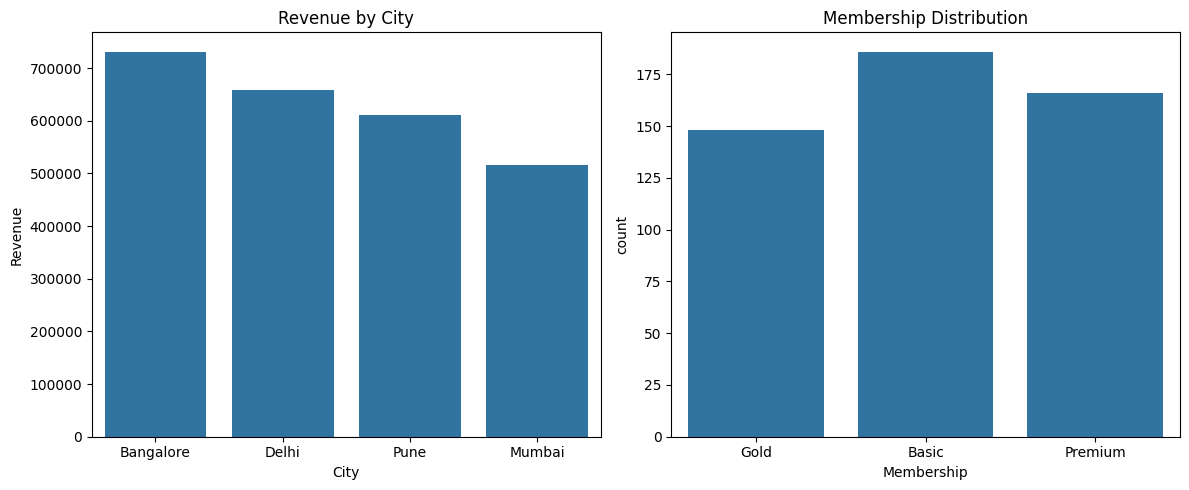

Report generated successfully!
shape: (4, 3)
┌───────────┬───────────────┬────────────┐
│ City      ┆ Revenue       ┆ Avg_Orders │
│ ---       ┆ ---           ┆ ---        │
│ str       ┆ f64           ┆ f64        │
╞═══════════╪═══════════════╪════════════╡
│ Bangalore ┆ 731262.565486 ┆ 9.432432   │
│ Delhi     ┆ 658191.097329 ┆ 11.229508  │
│ Pune      ┆ 610104.069073 ┆ 9.704918   │
│ Mumbai    ┆ 515587.402129 ┆ 9.388889   │
└───────────┴───────────────┴────────────┘


In [9]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Data
np.random.seed(42)
n = 500
df = pl.DataFrame({
    "Customer_ID": np.arange(1001, 1001 + n),
    "City": np.random.choice(["Delhi", "Mumbai", "Pune", "Bangalore"], n),
    "Membership": np.random.choice(["Basic", "Premium", "Gold"], n),
    "Total_Spending": np.random.normal(5000, 2000, n),
    "Total_Orders": np.random.randint(1, 20, n)
})

# 2. Pipeline & Feature Engineering
df = df.with_columns([
    (pl.col("Total_Spending") / pl.col("Total_Orders")).alias("AOV"), # Average Order Value
    pl.when(pl.col("Total_Spending") > 7000).then(pl.lit("VIP"))
      .when(pl.col("Total_Spending") > 4000).then(pl.lit("Regular"))
      .otherwise(pl.lit("Budget")).alias("Segment")
])

# 3. Industry Analytics (Groupby Aggregation)
summary = df.group_by("City").agg([
    pl.col("Total_Spending").sum().alias("Revenue"),
    pl.col("Total_Orders").mean().alias("Avg_Orders")
]).sort("Revenue", descending=True)

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Revenue by City
sns.barplot(data=summary.to_pandas(), x="City", y="Revenue", ax=axes[0])
axes[0].set_title("Revenue by City")

# Plot 2: Membership Distribution
sns.countplot(data=df.to_pandas(), x="Membership", ax=axes[1])
axes[1].set_title("Membership Distribution")

plt.tight_layout()
plt.show()

# 5. Export Report
summary.write_csv("ecommerce_report.csv")
print("Report generated successfully!")
print(summary)